In [1]:
from pathlib import Path

import numpy as onp
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
BASERESULTSDIR = Path("example_results/")

# TODO
PBCLABEL = "nonperiodic"
QUANTITY = "energy"

In [3]:
# resultsdirname = PBCLABEL
# results = pd.read_csv(BASERESULTSDIR / resultsdirname / "results.csv")

In [4]:
results = []

resultsdirname = PBCLABEL
df = pd.read_csv(BASERESULTSDIR / resultsdirname / "results.csv")
df.insert(len(df.columns), "double_precision", [False] * len(df))
results.append(df)

resultsdirname = PBCLABEL + "_doubleprec"
df = pd.read_csv(BASERESULTSDIR / resultsdirname / "results.csv")
df.insert(len(df.columns), "double_precision", [True] * len(df))
results.append(df)

results = pd.concat(results)

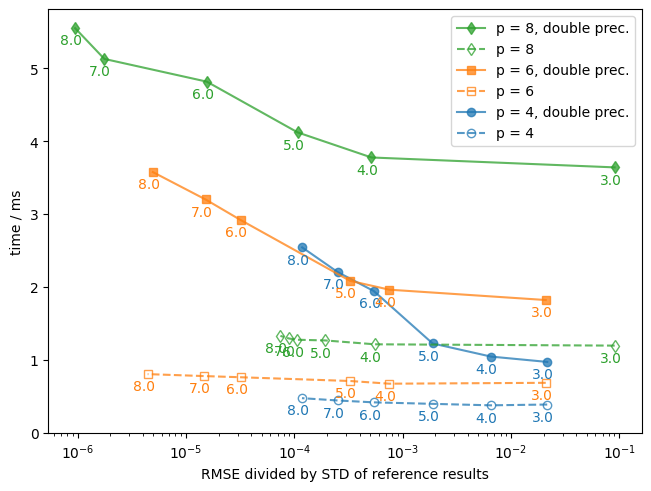

In [26]:
markerlist = ["o", "s", "d", "v", "^"]
# Settings for annotating the data points with the cutoff
# See https://matplotlib.org/stable/users/explain/artists/
ha = "center"
va = "top"
dx, dy = -3 / 72.0, -4 / 72.0  # x and y offsets in points

unique_ps = results.loc[results["quantity"] == QUANTITY, "p"].unique()
unique_ps = onp.sort(unique_ps)

fig, ax = plt.subplots(constrained_layout=True)
# fig, ax = plt.subplots()    # TODO

ax.set_xlabel("RMSE divided by STD of reference results")
ax.set_ylabel("time / ms")
ax.set_xscale("log")

offset = mpl.transforms.ScaledTranslation(dx, dy, fig.dpi_scale_trans)
annotations_transform = ax.transData + offset

for p, marker in zip(unique_ps, markerlist):
    for doubleprec, linestyle, markerfacecolor in zip(
        [False, True], ["--", "-"], ["none", None]
    ):
        selection = results.loc[
            (
                (results["p"] == p)
                & (results["quantity"] == QUANTITY)
                & (results["double_precision"] == doubleprec)
            )
        ]
        cutoffs = selection.level_zero_cutoff
        errors = selection.relative_rmse
        times = selection.time * 10**3
        if doubleprec:
            color = lines[0].get_color()
        else:
            color = None
        label = f"p = {p}"
        if doubleprec:
            label += ", double prec."
        lines = ax.plot(
            errors,
            times,
            alpha=0.75,
            marker=marker,
            markerfacecolor=markerfacecolor,
            linestyle=linestyle,
            color=color,
            label=label,
        )
        for r_cut, err, t in zip(cutoffs, errors, times):
            xy = (err, t)
            ax.annotate(
                str(r_cut),
                xy,
                xytext=xy,
                textcoords=annotations_transform,
                ha=ha,
                va=va,
                color=lines[0].get_color(),
            )

ax.set_ylim(bottom=0.0)
ax.legend(reverse=True)

plt.show()